# Detection de Fraude - Devoir Decision Tree

Ce notebook presente une demarche du devoir :
1. EDA 
2. Feature engineering de base
3. Decision tree
4. Optimisation  des hyperparametres
            


In [5]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)


## 1. Chargement des donnees
            


In [6]:
# Chargement du dataset principal.
df = pd.read_csv("Fraud Detection Dataset.csv")

print("Shape :", df.shape)
print("Colonnes :")
print(list(df.columns))
print(" Apercu :")
df.head()


Shape : (51000, 12)
Colonnes :
['Transaction_ID', 'User_ID', 'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction', 'Device_Used', 'Location', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method', 'Fraudulent']
 Apercu :


,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


## 2. EDA

On garde seulement quelques graphiques utiles et une conclusion apres chacun.


Valeurs manquantes :
Time_of_Transaction    2552
Location               2547
Transaction_Amount     2520
Device_Used            2473
Payment_Method         2469
dtype: int64


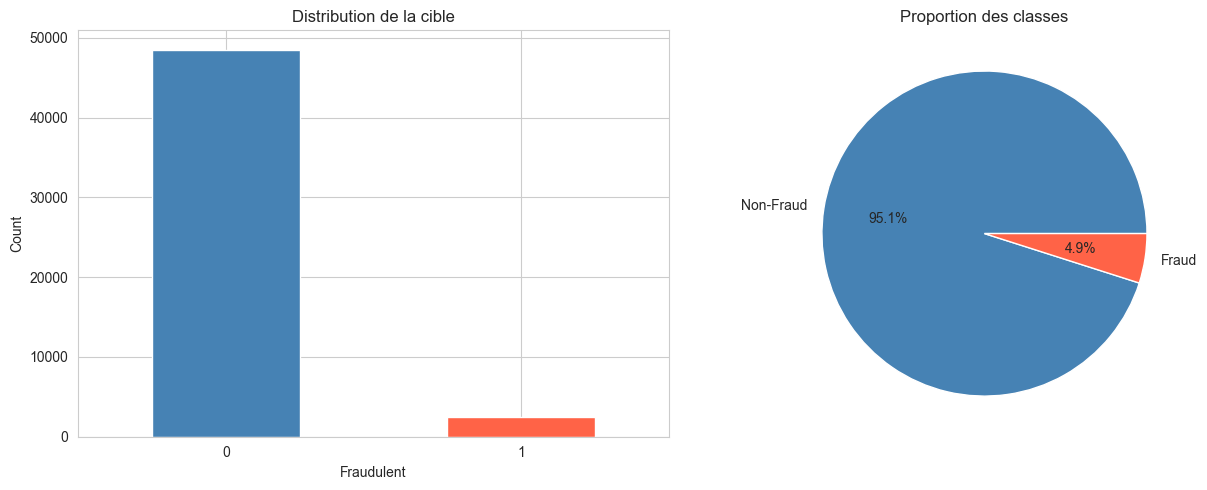

In [7]:
# Verification rapide des valeurs manquantes puis visualisation de la variable cible.
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Valeurs manquantes :")
print(missing if not missing.empty else "Aucune valeur manquante.")

fraud_rate = df["Fraudulent"].mean() * 100
target_counts = df["Fraudulent"].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
target_counts.plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"])
axes[0].set_title("Distribution de la cible")
axes[0].set_xlabel("Fraudulent")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

target_counts.plot(
    kind="pie",
    ax=axes[1],
    autopct="%1.1f%%",
    labels=["Non-Fraud", "Fraud"],
    colors=["steelblue", "tomato"],
)
axes[1].set_ylabel("")
axes[1].set_title("Proportion des classes")
plt.tight_layout()
plt.show()


**Conclusion :** la classe fraude est minoritaire, donc le jeu de donnees est desequilibre.


              count         mean          std    min       25%      50%  \
Fraudulent                                                                
0           46095.0  2989.931309  5010.290069   5.03  1272.255  2524.39   
1            2385.0  3118.367245  5654.749402  14.31  1222.260  2516.01   

                75%      max  
Fraudulent                    
0           3789.59  49997.8  
1           3738.62  49997.8  


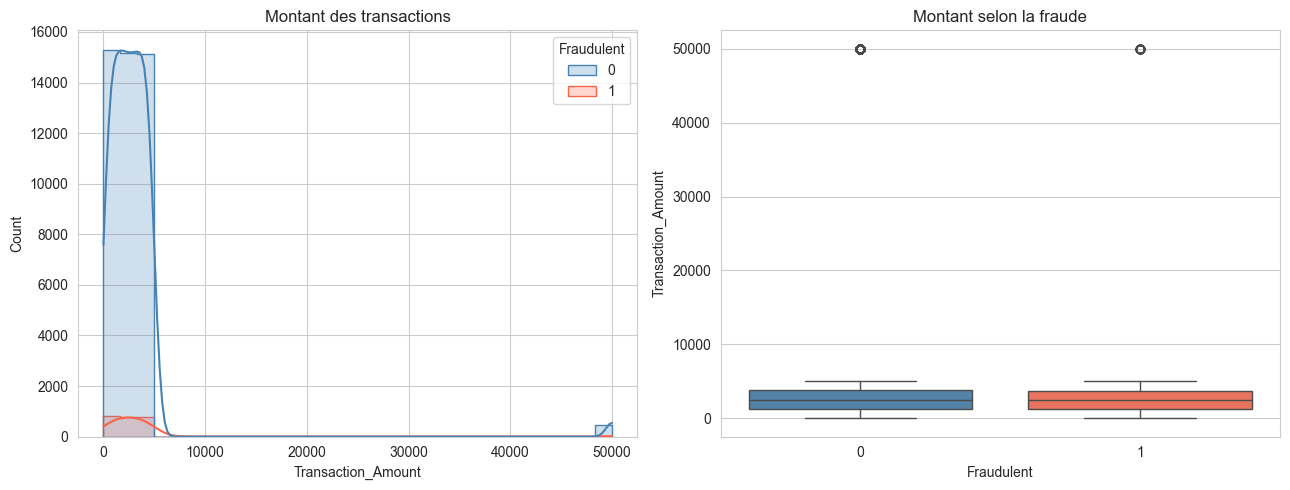

In [8]:
print(df.groupby("Fraudulent")["Transaction_Amount"].describe())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(
    data=df,
    x="Transaction_Amount",
    hue="Fraudulent",
    bins=30,
    kde=True,
    ax=axes[0],
    palette=["steelblue", "tomato"],
    element="step",
)
axes[0].set_title("Montant des transactions")

sns.boxplot(data=df, x="Fraudulent", y="Transaction_Amount", ax=axes[1], palette=["steelblue", "tomato"])
axes[1].set_title("Montant selon la fraude")
plt.tight_layout()
plt.show()


**Conclusion :** le montant seul ne separe pas parfaitement les deux classes, meme s'il peut apporter un signal.


Fraudulent                0         1
Transaction_Type                     
ATM Withdrawal    95.346320  4.653680
Bank Transfer     95.192682  4.807318
Bill Payment      95.048356  4.951644
Online Purchase   94.808797  5.191203
POS Payment       94.993087  5.006913


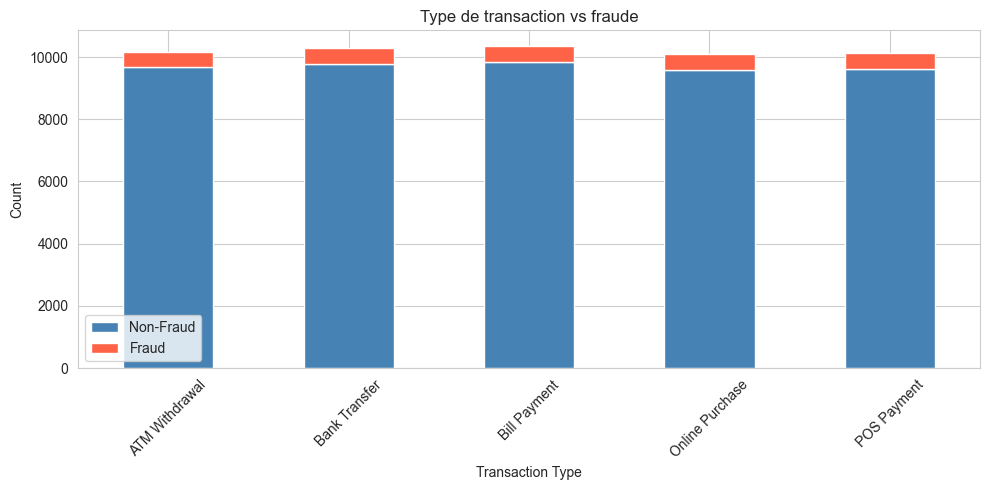

In [9]:
tx_fraud_rate = pd.crosstab(df["Transaction_Type"], df["Fraudulent"], normalize="index") * 100
tx_counts = pd.crosstab(df["Transaction_Type"], df["Fraudulent"])
print(tx_fraud_rate)

tx_counts.plot(kind="bar", stacked=True, color=["steelblue", "tomato"], figsize=(10, 5))
plt.title("Type de transaction vs fraude")
plt.xlabel("Transaction Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(["Non-Fraud", "Fraud"])
plt.tight_layout()
plt.show()


**Conclusion :** certains types de transaction semblent plus associes a la fraude que d'autres.


Fraudulent              0         1
Payment_Method                     
Credit Card     95.071269  4.928731
Debit Card      95.153364  4.846636
Invalid Method  95.228758  4.771242
Net Banking     95.079719  4.920281
UPI             94.851518  5.148482


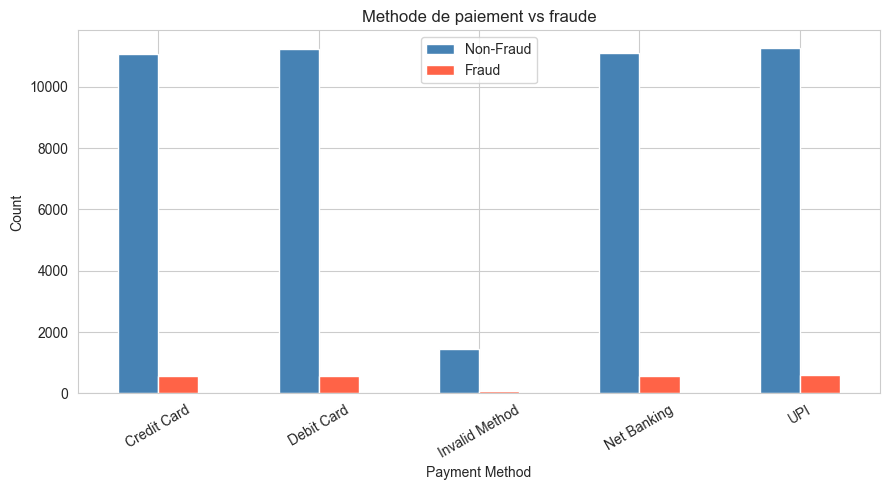

In [10]:
payment_fraud_rate = pd.crosstab(df["Payment_Method"], df["Fraudulent"], normalize="index") * 100
payment_counts = pd.crosstab(df["Payment_Method"], df["Fraudulent"])
print(payment_fraud_rate)

payment_counts.plot(kind="bar", color=["steelblue", "tomato"], figsize=(9, 5))
plt.title("Methode de paiement vs fraude")
plt.xlabel("Payment Method")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.legend(["Non-Fraud", "Fraud"])
plt.tight_layout()
plt.show()


**Conclusion :** la methode de paiement peut aussi jouer un role dans la detection.


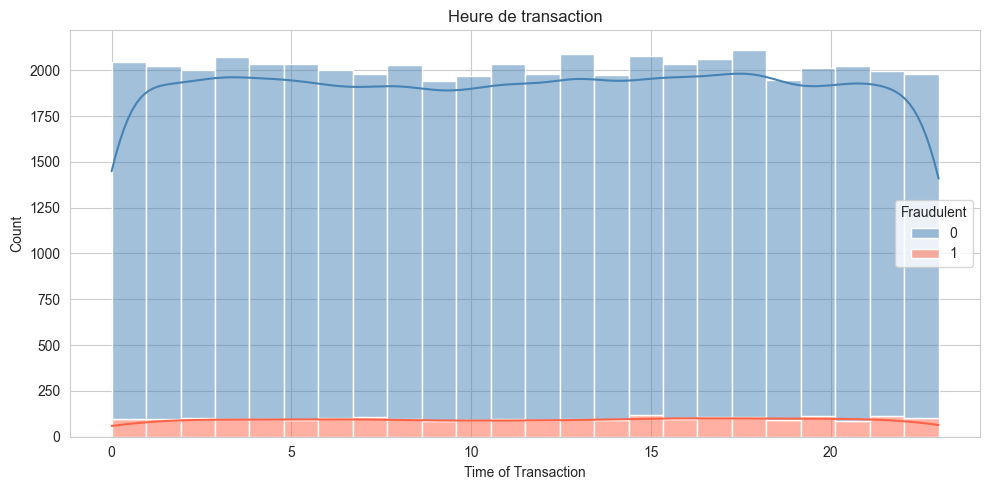

In [11]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Time_of_Transaction",
    hue="Fraudulent",
    bins=24,
    kde=True,
    palette=["steelblue", "tomato"],
    multiple="stack",
)
plt.title("Heure de transaction")
plt.xlabel("Time of Transaction")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**Conclusion :** l'heure de transaction semble etre une variable utile a conserver.


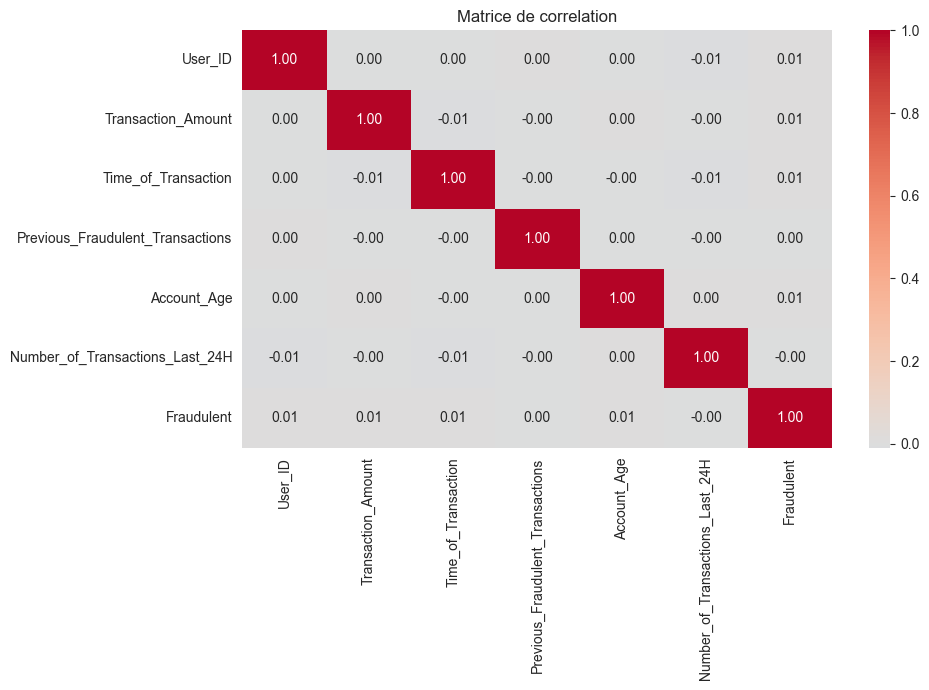

In [12]:
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de correlation")
plt.tight_layout()
plt.show()


**Conclusion :** les correlations avec la cible restent plutot moderees, donc plusieurs variables devront etre combinees.


## 3. Feature engineering

On garde seulement quelques transformations simples et faciles a expliquer.
            


In [13]:
# Copie de travail pour ne pas modifier le dataset d'origine.
df_model = df.copy()

# Remplissage simple des valeurs manquantes.
df_model["Transaction_Amount"] = df_model.groupby("Transaction_Type")["Transaction_Amount"].transform(
    lambda x: x.fillna(x.median())
)
df_model["Time_of_Transaction"] = df_model["Time_of_Transaction"].fillna(df_model["Time_of_Transaction"].median())
df_model["Device_Used"] = df_model["Device_Used"].fillna(df_model["Device_Used"].mode()[0])
df_model["Location"] = df_model["Location"].fillna(df_model["Location"].mode()[0])
df_model["Payment_Method"] = df_model["Payment_Method"].fillna(df_model["Payment_Method"].mode()[0])

# Quelques variables construites faciles a justifier dans un devoir.
df_model["Amount_per_Account_Age"] = df_model["Transaction_Amount"] / (df_model["Account_Age"] + 1)
df_model["Transaction_Frequency_Ratio"] = df_model["Number_of_Transactions_Last_24H"] / (df_model["Account_Age"] + 1)
df_model["High_Amount"] = (df_model["Transaction_Amount"] > df_model["Transaction_Amount"].quantile(0.75)).astype(int)
df_model["Is_New_Account"] = (df_model["Account_Age"] <= 30).astype(int)

# Regroupement de l'heure en grandes periodes de la journee.
def time_bucket(hour):
    if pd.isna(hour):
        return "Unknown"
    hour = float(hour)
    if 6 <= hour < 12:
        return "Morning"
    if 12 <= hour < 18:
        return "Afternoon"
    if 18 <= hour < 22:
        return "Evening"
    return "Night"

df_model["Time_Category"] = df_model["Time_of_Transaction"].apply(time_bucket)

# Encodage des variables categorielles pour l'arbre de decision.
for col in ["Transaction_Type", "Device_Used", "Location", "Payment_Method", "Time_Category"]:
    encoder = LabelEncoder()
    df_model[f"{col}_encoded"] = encoder.fit_transform(df_model[col].astype(str))

feature_cols = [
    "Transaction_Amount",
    "Time_of_Transaction",
    "Previous_Fraudulent_Transactions",
    "Account_Age",
    "Number_of_Transactions_Last_24H",
    "Amount_per_Account_Age",
    "Transaction_Frequency_Ratio",
    "High_Amount",
    "Is_New_Account",
    "Transaction_Type_encoded",
    "Device_Used_encoded",
    "Location_encoded",
    "Payment_Method_encoded",
    "Time_Category_encoded",
]

X = df_model[feature_cols]
y = df_model["Fraudulent"]

print("Variables retenues :")
print(feature_cols)
print()
print("Shape de X :", X.shape)


Variables retenues :
['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H', 'Amount_per_Account_Age', 'Transaction_Frequency_Ratio', 'High_Amount', 'Is_New_Account', 'Transaction_Type_encoded', 'Device_Used_encoded', 'Location_encoded', 'Payment_Method_encoded', 'Time_Category_encoded']

Shape de X : (51000, 14)


## 4. Modelisation

On commence par une baseline simple, puis on applique une optimisation des hyperparametres.


In [14]:
# Separation train/test avec stratification pour garder le desequilibre initial.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Baseline : arbre de decision avec les parametres par defaut.
baseline_model = DecisionTreeClassifier(random_state=42)
baseline_model.fit(X_train, y_train)

baseline_test_pred = baseline_model.predict(X_test)
baseline_test_proba = baseline_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    "Accuracy": accuracy_score(y_test, baseline_test_pred),
    "Precision": precision_score(y_test, baseline_test_pred, zero_division=0),
    "Recall": recall_score(y_test, baseline_test_pred, zero_division=0),
    "F1-score": f1_score(y_test, baseline_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, baseline_test_proba),
}

print("Resultats de la baseline :")
for metric, value in baseline_metrics.items():
    print(f"{metric} : {value:.4f}")

print()
print("Classification report - baseline :")
print(classification_report(y_test, baseline_test_pred, target_names=["Non-Fraud", "Fraud"]))


Resultats de la baseline :
Accuracy : 0.8982
Precision : 0.0826
Recall : 0.1056
F1-score : 0.0927
ROC-AUC : 0.5224

Classification report - baseline :
              precision    recall  f1-score   support

   Non-Fraud       0.95      0.94      0.95      9698
       Fraud       0.08      0.11      0.09       502

    accuracy                           0.90     10200
   macro avg       0.52      0.52      0.52     10200
weighted avg       0.91      0.90      0.90     10200



**Conclusion :** cette baseline sert de point de depart avant l'optimisation des hyperparametres.


Meilleurs hyperparametres :
{'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 2}
F1 moyen CV : 0.0929

Resultats apres optimisation :
Accuracy : 0.5585
Precision : 0.0448
Recall : 0.3924
F1-score : 0.0805
ROC-AUC : 0.4803

Comparaison baseline vs modele optimise :
           Baseline  Optimise      Gain
Accuracy   0.898235  0.558529 -0.339706
Precision  0.082555  0.044824 -0.037731
Recall     0.105578  0.392430  0.286853
F1-score   0.092657  0.080457 -0.012200
ROC-AUC    0.522422  0.480291 -0.042131


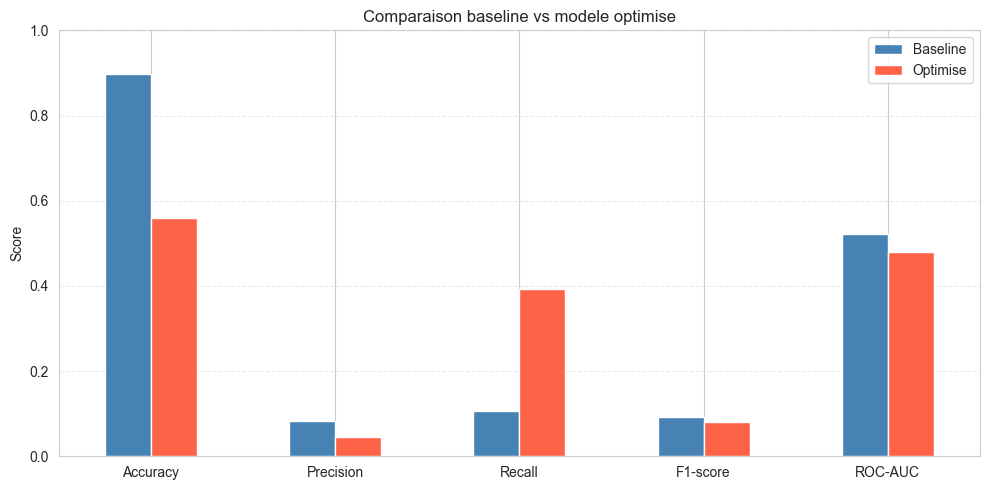


Classification report - modele optimise :
              precision    recall  f1-score   support

   Non-Fraud       0.95      0.57      0.71      9698
       Fraud       0.04      0.39      0.08       502

    accuracy                           0.56     10200
   macro avg       0.50      0.48      0.39     10200
weighted avg       0.90      0.56      0.68     10200



In [15]:
# Grille simple d'hyperparametres pour ameliorer la baseline.
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 10, 20],
    "min_samples_leaf": [1, 5, 10],
    "class_weight": ["balanced", None],
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
)

# Entrainement du modele optimise.
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

y_train_pred = best_model.predict(X_train)
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

optimized_metrics = {
    "Accuracy": accuracy_score(y_test, y_test_pred),
    "Precision": precision_score(y_test, y_test_pred, zero_division=0),
    "Recall": recall_score(y_test, y_test_pred, zero_division=0),
    "F1-score": f1_score(y_test, y_test_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_test_proba),
}

print("Meilleurs hyperparametres :")
print(grid_search.best_params_)
print(f"F1 moyen CV : {grid_search.best_score_:.4f}")

print()
print("Resultats apres optimisation :")
for metric, value in optimized_metrics.items():
    print(f"{metric} : {value:.4f}")

comparison = pd.DataFrame(
    {"Baseline": baseline_metrics, "Optimise": optimized_metrics}
)
comparison["Gain"] = comparison["Optimise"] - comparison["Baseline"]

print()
print("Comparaison baseline vs modele optimise :")
print(comparison)

# Graphique simple pour comparer les metriques avant et apres optimisation.
comparison[["Baseline", "Optimise"]].plot(
    kind="bar",
    figsize=(10, 5),
    color=["steelblue", "tomato"]
)
plt.title("Comparaison baseline vs modele optimise")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

print()
print("Classification report - modele optimise :")
print(classification_report(y_test, y_test_pred, target_names=["Non-Fraud", "Fraud"]))


**Conclusion :** le tableau et le graphique permettent de voir si l'optimisation apporte un gain par rapport a la baseline, surtout sur le F1-score.


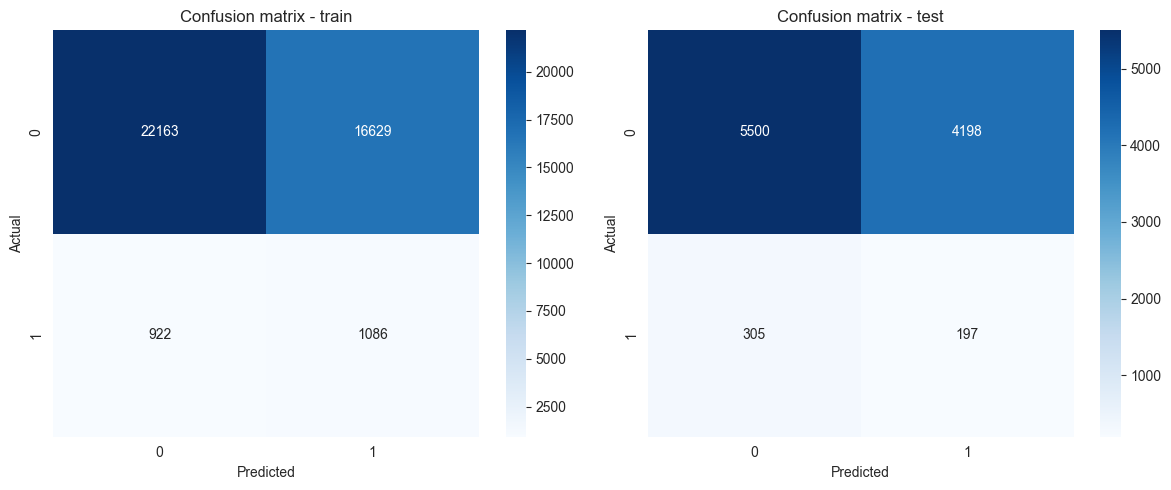

In [16]:
# La matrice de confusion permet de voir ou le modele optimise se trompe.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.heatmap(confusion_matrix(y_train, y_train_pred), annot=True, fmt="d", cmap="Blues", ax=axes[0])
axes[0].set_title("Confusion matrix - train")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(confusion_matrix(y_test, y_test_pred), annot=True, fmt="d", cmap="Blues", ax=axes[1])
axes[1].set_title("Confusion matrix - test")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()


**Conclusion :** le modele optimise detecte une partie des fraudes, mais la classe minoritaire reste difficile.


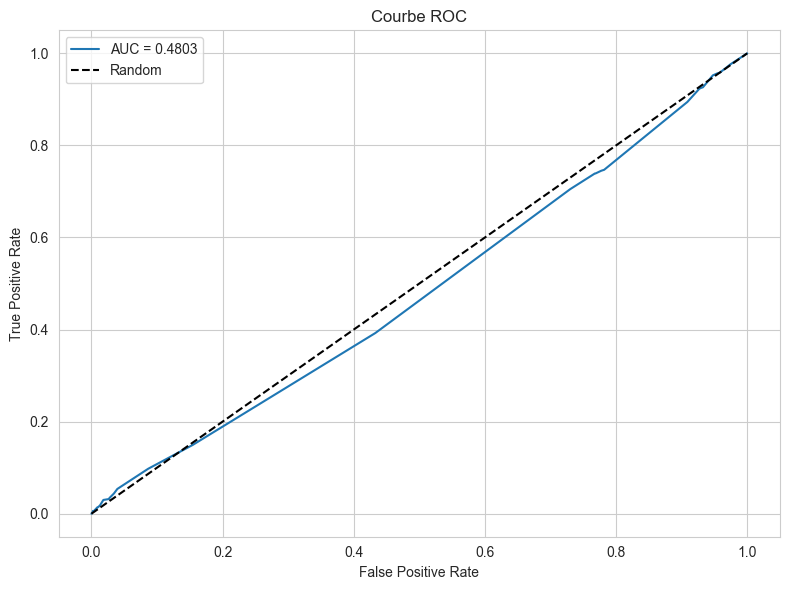

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Courbe ROC")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


**Conclusion :** la courbe ROC donne une vue globale de la capacite de separation du modele optimise.


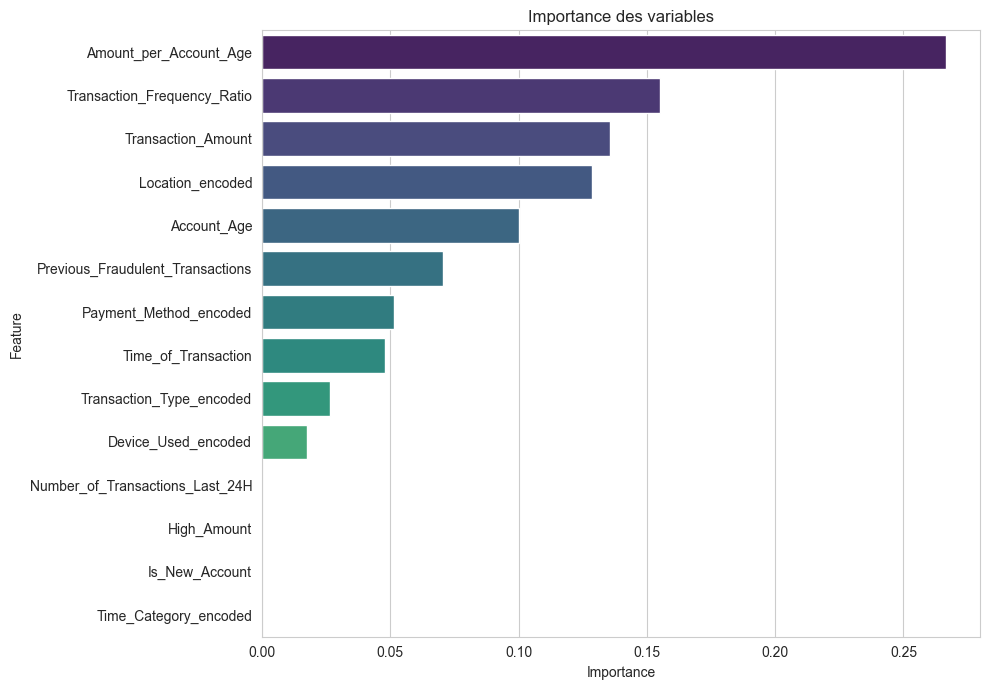

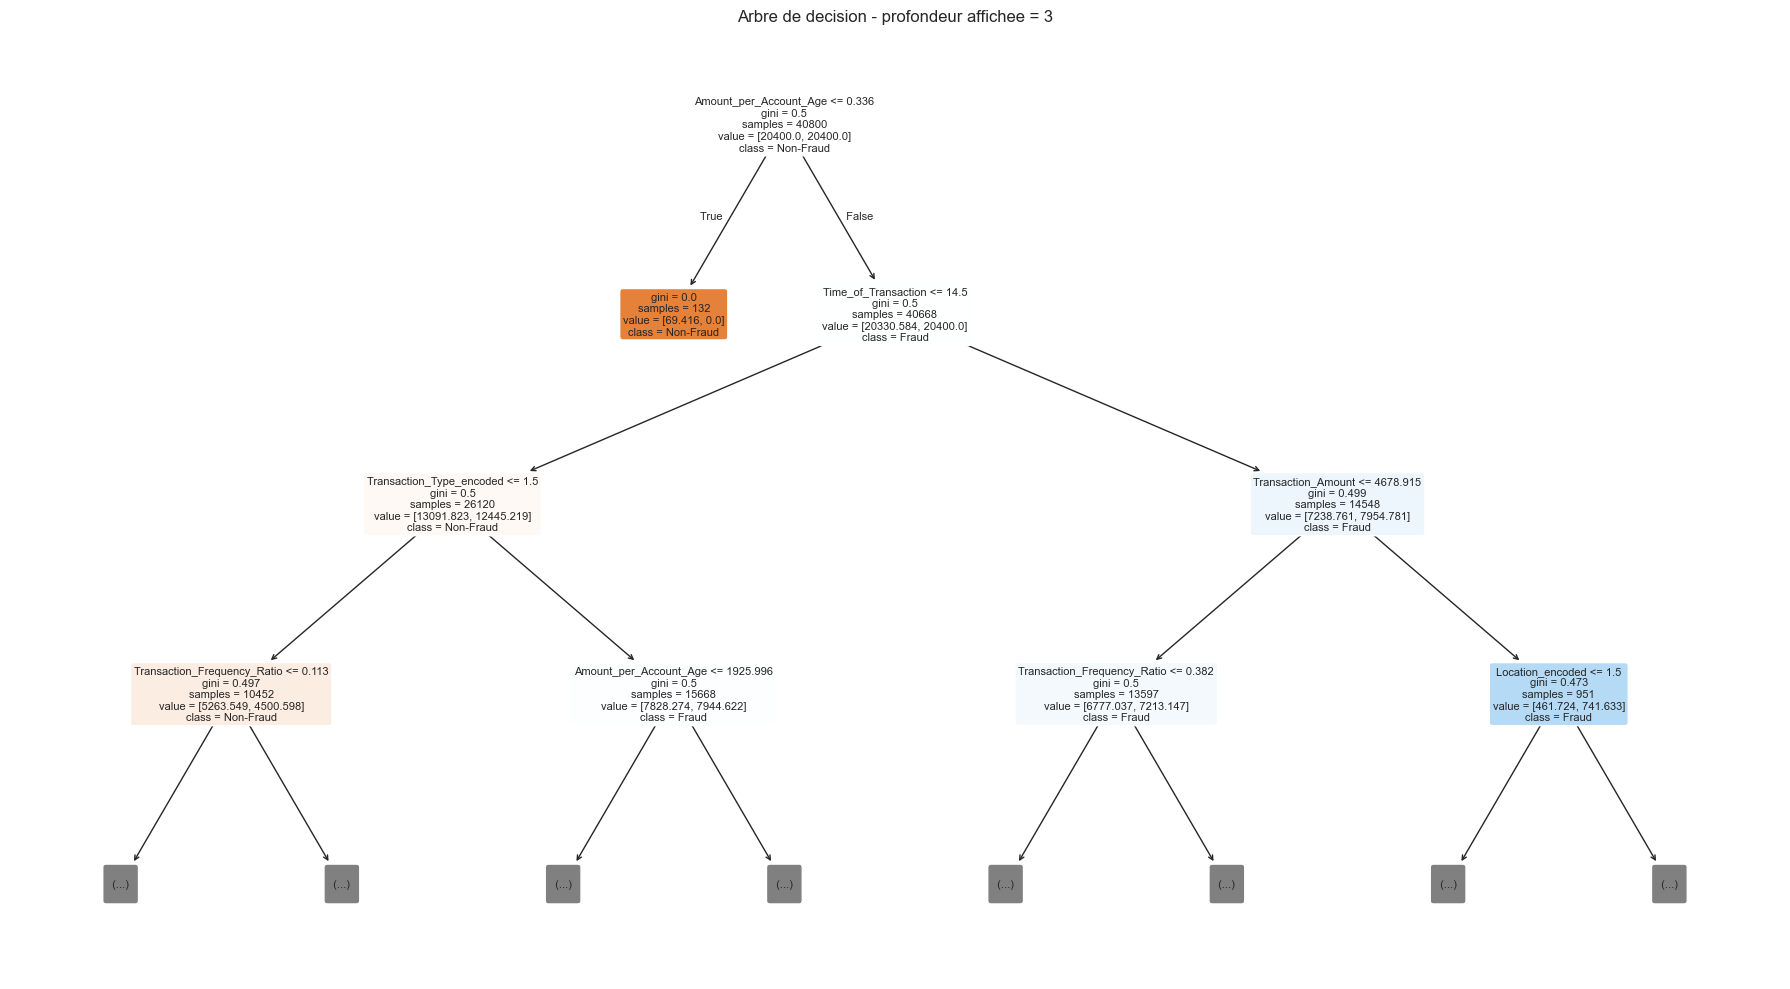

,Feature,Importance
5,Amount_per_Account_Age,0.266517
6,Transaction_Frequency_Ratio,0.155110
0,Transaction_Amount,0.135543
11,Location_encoded,0.128622
3,Account_Age,0.100189


In [18]:
# Classement des variables selon leur importance dans l'arbre.
feature_importance = pd.DataFrame(
    {"Feature": feature_cols, "Importance": best_model.feature_importances_}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 7))
sns.barplot(data=feature_importance, x="Importance", y="Feature", palette="viridis")
plt.title("Importance des variables")
plt.tight_layout()
plt.show()

# On affiche seulement les premiers niveaux pour garder un schema lisible.
plt.figure(figsize=(18, 10))
plot_tree(
    best_model,
    feature_names=feature_cols,
    class_names=["Non-Fraud", "Fraud"],
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=3,
)
plt.title("Arbre de decision - profondeur affichee = 3")
plt.tight_layout()
plt.show()

feature_importance.head()


**Conclusion :** les variables les plus importantes ressortent clairement, et l'arbre reste assez interpretable pour un devoir de base.


## Conclusion generale

**Remarques sur les donnees :** le jeu de donnees est desequilibre, avec peu de fraudes par rapport aux transactions normales. Cela rend la detection plus difficile et explique pourquoi certaines metriques restent faibles.

**Remarques sur le modele :** le decision tree est un bon choix de base pour un devoir, car il est simple a expliquer, rapide a entrainer et facile a interpreter. La baseline permet de fixer un point de depart, puis le tuning montre l'effet de l'optimisation.

**Remarques sur les resultats :** les resultats restent limites, et l'AUC est faible, ce qui montre que le modele distingue encore mal les transactions frauduleuses des transactions normales. Autrement dit, ce decision tree reste surtout une baseline de travail, utile pour illustrer une demarche simple d'EDA, de feature engineering et d'optimisation.
